# Self-Improving AI Agents, Governed — DejaDB + Waiser

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AreevAI/dejadb/blob/main/examples/colab/self_improving_agents.ipynb)
[![PyPI](https://img.shields.io/pypi/v/dejadb)](https://pypi.org/project/dejadb/)
[![GitHub](https://img.shields.io/badge/GitHub-AreevAI%2Fdejadb-black)](https://github.com/AreevAI/dejadb)

An enterprise support-agent walkthrough, end to end: the agent works, its memory
notices what keeps going wrong, proposes fixes, a human reviews each one with a
recorded reason, and the system later **measures** whether each applied fix held.
Every step is audited; every change is reversible.

What makes this demo different from most "agent memory" demos:

- **No server.** `pip install dejadb` and everything runs in-process. One memory = one file.
- **No API key needed.** The core self-improvement loop is driven by 11 deterministic
  analyzers — it runs identically in an air-gapped environment. (There is one
  *optional* LLM cell near the end.)
- **Governed by default.** Nothing is ever auto-applied unless a policy file explicitly
  grants it. Approvals, rejections, and rollbacks all require a `because` reason.

Runtime: ~2 minutes on a free Colab CPU. Works in any Jupyter environment
(Linux x86_64/arm64, macOS, Windows — prebuilt wheels for all).

## 0 · Install

One wheel, no compiler, no daemon.

In [1]:
%pip install -q dejadb matplotlib networkx

import dejadb, json, os, pathlib, shutil

# start from a clean slate so the notebook is re-runnable
for f in pathlib.Path(".").glob("support.db*"):
    shutil.rmtree(f) if f.is_dir() else f.unlink()

print("dejadb", dejadb.__version__)

Note: you may need to restart the kernel to use updated packages.
dejadb 1.0.3


## 1 · Memory that can testify

Enterprise memory has to answer *"why does the agent believe this?"* — months later,
to an auditor. DejaDB stores every memory as an **immutable, content-addressed grain**
(the hash is the SHA-256 of the grain's canonical bytes). Nothing is ever edited in
place: an update is a *supersession*, a deletion is a *tombstone*. The full history
stays queryable.

In [2]:
db = dejadb.DejaDB("support.db", ns="support", actor="user:demo")
# actor labels every decision in the audit chain.
# (Add passphrase="..." for AES-256-GCM encryption at rest — same one-line open.)

h = db.add_fact("acme-corp", "plan", "starter", confidence=0.95)
db.add_fact("acme-corp", "sso_provider", "okta")
db.add_fact("acme-corp", "region", "eu-west-1")
db.add_fact("ticket-1042", "status", "open")

print("content address:", h)
for g in json.loads(db.recall("acme-corp")):
    f = g["fields"]
    print(f"  {f['subject']} --{f['relation']}--> {f['object']}")

content address: a04e565692b7bd601e3b3306c774cf1920dd7ca340b74d6efb73f13e2159100e
  acme-corp --region--> eu-west-1
  acme-corp --sso_provider--> okta
  acme-corp --plan--> starter


Acme upgrades their plan. We don't edit the old fact — we **supersede** it, and the
chain of custody is preserved:

In [3]:
db.supersede(h, "fact", json.dumps(
    {"subject": "acme-corp", "relation": "plan", "object": "enterprise"}))

print("current head:", json.loads(db.latest("acme-corp", "plan"))["fields"]["object"])
print()
print("full history (newest first):")
for v in json.loads(db.history("acme-corp", "plan")):
    marker = "superseded" if v["superseded_by"] else "LIVE      "
    print(f"  [{marker}] {v['object']!r}  hash={v['hash'][:12]}…")

print()
print("integrity check:", db.verify())   # re-hashes every grain; raises on tampering

current head: enterprise

full history (newest first):
  [LIVE      ] 'enterprise'  hash=6819ce040c9d…
  [superseded] 'starter'  hash=a04e565692b7…

integrity check: {"grains":5,"integrity":"ok"}


Free-text recall works out of the box (BM25 index is on by default) via **CAL** —
DejaDB's query language. No embeddings required yet:

In [4]:
hits = json.loads(db.cal('RECALL facts ABOUT "which region is acme in" | LIMIT 3'))
for g in hits["grains"]:
    f = g["fields"]
    print(f"  score={g['score']:.2f}  {f['subject']} --{f['relation']}--> {f['object']}")

  score=1.00  acme-corp --region--> eu-west-1
  score=1.00  acme-corp --plan--> enterprise
  score=1.00  acme-corp --sso_provider--> okta


## 2 · The agent at work (and where it hurts)

Wiring an agent to DejaDB is three habits, one line each:

1. **recall before acting** — `db.recall(subject)`
2. **record every tool call** — `db.record_tool_call(name, result, is_error=…)`
3. **remember what happened** — `db.remember(episode, facts_json=…)`

Our support agent depends on a CRM lookup tool that has started timing out.
Watch episode 1 the *naive* way — no lessons in memory yet:

In [5]:
# A simulated flaky enterprise API: times out on the first 4 attempts.
def crm_lookup(account, attempt):
    if attempt < 5:
        raise TimeoutError("timeout after 30s")
    return {"account": account, "plan": "enterprise", "csm": "Dana"}

def run_episode_1(db):
    lessons = json.loads(db.recall("crm_lookup"))
    print(f"lessons about crm_lookup in memory: {len(lessons)}")
    errors = calls = 0
    for attempt in range(1, 6):                      # naive retry loop
        calls += 1
        try:
            result = crm_lookup("acme-corp", attempt)
            db.record_tool_call("crm_lookup", json.dumps(result), thread="ep-1")
            break
        except TimeoutError as e:
            errors += 1
            db.record_tool_call("crm_lookup", f"{e} (attempt {attempt})",
                                is_error=True, thread="ep-1")
    print(f"episode 1: {calls} tool calls, {errors} timeouts before an answer")
    return {"calls": calls, "errors": errors}

ep1 = run_episode_1(db)

lessons about crm_lookup in memory: 0
episode 1: 5 tool calls, 4 timeouts before an answer


The agent also **remembers the episode** — as an Observation with pre-extracted,
provenance-linked Facts — and meanwhile two teammates disagree about a ticket
(a second live value lands under a functional relation):

In [6]:
out = json.loads(db.remember(
    "Resolved Acme's SSO ticket after repeated CRM timeouts; confirmed rollout done.",
    facts_json=json.dumps([
        {"subject": "ticket-1042", "relation": "root_cause",
         "object": "SAML clock skew", "confidence": 0.9},
    ]),
    observer="agent:support-bot"))
print("episode stored:", out["observation"][:12], "→ facts:", [h[:12] for h in out["facts"]])

# a colleague marks the ticket resolved — but "open" is still live: a contradiction
db.add_fact("ticket-1042", "status", "resolved")

# and a promo fact carries an expiry that has passed ("vt" = valid_to, epoch ms)
import time
db.add("fact", json.dumps({
    "subject": "promo-2025", "relation": "discount_code", "object": "SAVE20",
    "vt": int(time.time() * 1000) - 30 * 24 * 3600 * 1000}))

print("seeded: 1 contradiction + 1 expired fact + 4 recorded tool failures")

episode stored: 906c8fee52bc → facts: ['7acf87cf7e0f']
seeded: 1 contradiction + 1 expired fact + 4 recorded tool failures


## 3 · Waiser: governed self-improvement

**Waiser** is DejaDB's self-improvement engine. Four gates, in order:

| Gate | What it enforces |
|---|---|
| **Propose** | Only structured recommendation objects enter the queue — versioned analyzer id, template-rendered summary, bounded evidence hashes, severity. Analyzers cannot emit free prose. |
| **Review** | Separation of duties; a **mandatory `because` reason**; self-approval blocked. |
| **Apply** | Destructive payloads additionally require an explicit `allow_destructive` opt-in. Every apply records its inverse. |
| **Verify** | The applied change is re-measured at 1d/7d/30d checkpoints — *held* or *regressed* — and a regression proposes its own revert. |

11 built-in analyzers (10 on by default) are **deterministic** — same memory in,
same recommendations out. Test-enforced precision ≥ 0.90 per analyzer
([bench results](https://github.com/AreevAI/dejadb/blob/main/crates/dejadb-bench/RESULTS.md)).
No LLM in the loop unless you add one (§7). Run a full sweep:

In [7]:
run = json.loads(db.waiser_run(full_sweep=True))
print(f"outcome: {run['outcome']} — {len(run['analyzers_run'])} analyzers, "
      f"{run['proposed']} proposed, {run['stored']} stored, "
      f"{run['auto_applied']} auto-applied")
print()

pending = json.loads(db.recommendations('{"status":"pending"}'))
for r in pending:
    tag = "DESTRUCTIVE" if r["destructive"] else "reversible "
    print(f"  [{r['severity']:6}] [{tag}] {r['analyzer']}")
    print(f"           {r['summary']}")

outcome: ran — 10 analyzers, 3 proposed, 3 stored, 0 auto-applied

  [low   ] [DESTRUCTIVE] waiser.staleness/1
           Expire "promo-2025": past its declared valid_to (30d ago)
  [medium] [reversible ] waiser.tool_failure/1
           Tool "crm_lookup" failed 4 times (80% of calls): timeout after #s (attempt #)
  [medium] [reversible ] waiser.contradiction_sweep/1
           "ticket-1042" holds 2 live values for functional relation "status"


`auto_applied: 0` — by design. Now the human (or a supervising agent) reviews.
Every decision needs a reason, and the reason is stored in the audit chain.

**Apply** the tool-failure lesson and the contradiction fix:

In [8]:
by = {r["analyzer"].split(".")[1].split("/")[0]: r for r in pending}

res = db.apply_recommendation(
    by["tool_failure"]["hash"],
    because="timeouts confirmed in the ops dashboard; teach the agent to fall back")
print("applied tool_failure  →", res)

res = db.apply_recommendation(
    by["contradiction_sweep"]["hash"],
    because="'resolved' is correct — CRM export lagged behind the ticket system")
print("applied contradiction →", res)

# the contradiction fix is a supersession, not a deletion — history intact:
print()
print("ticket-1042 status now:",
      json.loads(db.latest("ticket-1042", "status"))["fields"]["object"],
      f"({len(json.loads(db.history('ticket-1042','status')))} versions in history)")

applied tool_failure  → {"hash":"d8748b1e1229bd58ee558bbe627a7e372b7fcf9f672dd7e294fc536307afc707","rollbackable":true}
applied contradiction → {"hash":"fbcf993a05cf0eea89140ffb7748c7ce938074d6073cc2a54c7b101b4047c372","rollbackable":true}

ticket-1042 status now: resolved (2 versions in history)


The staleness recommendation wants to **tombstone** the expired promo. Two layers
of protection apply. First, it's flagged `destructive` — trying to apply it without
an explicit `allow_destructive=True` is refused by the apply gate
(`WSR-E023 destructive apply gated: destructive apply requires admin scope +
allow_destructive`), because destructive applies have no inverse to roll back to.
Second, human judgment gets the last word — and here it says no. **Dismiss, with a
reason that goes in the audit trail:**

In [9]:
res = db.dismiss_recommendation(
    by["staleness"]["hash"],
    "under legal hold — retain until the 2027 audit closes")
print("dismissed →", res)

dismissed → {"hash":"020389edccdc386b8554bda6a45fe3c2dd6a7235d9c34b0e1ee92f1e767b3779","status":"rejected"}


## 4 · The loop closes — measurably

The applied lesson is now an ordinary, recallable fact. Episode 2: the *same agent
code pattern* — recall before acting — now finds the lesson and answers from
memory instead of hammering the broken tool:

In [10]:
def run_episode_2(db):
    lessons = json.loads(db.recall("crm_lookup"))
    for g in lessons:
        f = g["fields"]
        print(f"lesson found: crm_lookup --{f['relation']}--> {f['object']!r}")
    if any(g["fields"]["relation"] == "fails_with" for g in lessons):
        # fall back to what memory already knows about the account
        facts = {g["fields"]["relation"]: g["fields"]["object"]
                 for g in json.loads(db.recall("acme-corp"))}
        print(f"answered from memory: plan={facts['plan']}, region={facts['region']}")
        return {"calls": 0, "errors": 0}

ep2 = run_episode_2(db)
print()
print(f"{'':12}{'tool calls':>12}{'timeouts':>10}")
print(f"{'episode 1':12}{ep1['calls']:>12}{ep1['errors']:>10}   (no lessons)")
print(f"{'episode 2':12}{ep2['calls']:>12}{ep2['errors']:>10}   (lesson applied + reviewed)")

lesson found: crm_lookup --fails_with--> 'timeout after #s (attempt #)'
answered from memory: plan=enterprise, region=eu-west-1

              tool calls  timeouts
episode 1              5         4   (no lessons)
episode 2              0         0   (lesson applied + reviewed)


Same numbers, screenshot-ready:

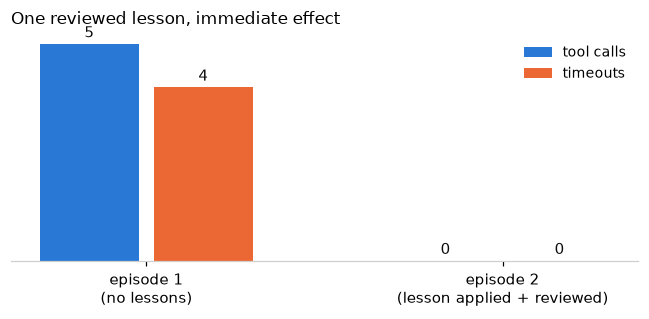

In [11]:
import matplotlib.pyplot as plt

episodes = ["episode 1\n(no lessons)", "episode 2\n(lesson applied + reviewed)"]
series = [("tool calls", "#2a78d6", [ep1["calls"], ep2["calls"]]),
          ("timeouts",   "#eb6834", [ep1["errors"], ep2["errors"]])]

fig, ax = plt.subplots(figsize=(6, 3), dpi=110)
w = 0.32
for i, (name, color, vals) in enumerate(series):
    xs = [x + (i - 0.5) * w for x in range(len(episodes))]
    bars = ax.bar(xs, vals, width=w - 0.04, color=color, label=name)
    ax.bar_label(bars, padding=2, fontsize=10, color="#0b0b0b")
ax.set_xticks(range(len(episodes)), episodes, fontsize=10)
ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.spines["bottom"].set_visible(True); ax.spines["bottom"].set_color("#d0cfcb")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_title("One reviewed lesson, immediate effect", fontsize=11, loc="left")
plt.tight_layout(); plt.show()

**The Verify gate.** Waiser doesn't just apply and hope — it re-measures each
applied recommendation against its recorded baseline at later checkpoints.
`WAISER_NOW_MS` is DejaDB's documented clock-pin seam (used by its own test suite),
so we can fast-forward two days *inside this cell* and watch the measurement land:

In [12]:
import time
os.environ["WAISER_NOW_MS"] = str(int(time.time() * 1000) + 2 * 24 * 3600 * 1000)
db.waiser_run(full_sweep=True)          # a routine run 2 "days" later
del os.environ["WAISER_NOW_MS"]

for o in json.loads(db.waiser_outcomes()):
    print(f"  {o['metric']:28} baseline={o['baseline']:.2f} → current={o['current']:.2f}  "
          f"verdict: {o['verdict'].upper()}  (horizon {o['horizon_ms']//86400000}d)")

  tool_error_recurrence        baseline=0.00 → current=0.00  verdict: HELD  (horizon 1d)
  contradiction_recurrence     baseline=0.00 → current=0.00  verdict: HELD  (horizon 1d)


> A separate `outcome_review` analyzer watches these outcomes and **proposes a
> revert** if an applied change regresses. Self-improvement with a feedback loop,
> not write-and-forget.

## 5 · Policy-as-code: earning autonomy

Auto-apply is never a checkbox in a UI — it can only be granted by a **host policy
file**, scoped per analyzer, per target, with a severity ceiling. (The web console
and MCP surface deliberately *cannot* grant it.) Typical team policy: structural
cleanup may self-apply at low severity; everything else still queues for review.

In [13]:
policy = {
    "auto_apply_enabled": True,
    "auto_apply": [
        {"analyzer": "waiser.duplicate_sweep", "targets": ["memory"], "max_severity": "low"}
    ],
    "deny": [], "severity_floors": {}, "telemetry": "aggregate",
}
pathlib.Path("waiser-policy.json").write_text(json.dumps(policy, indent=2))

# seed an exact duplicate fact — the classic "two ingest pipelines" artifact
db.add_fact("acme-corp", "support_tier", "priority")
db.add_fact("acme-corp", "support_tier", "priority")

run = json.loads(db.waiser_run(full_sweep=True, policy="waiser-policy.json"))
print(f"proposed={run['proposed']}  auto_applied={run['auto_applied']}  "
      f"(dedup self-applied under policy; still logged, still reversible)")

proposed=4  auto_applied=1  (dedup self-applied under policy; still logged, still reversible)


**Reversibility.** Suppose the contradiction fix turns out to be wrong next week —
roll it back, with a reason, and the grains it created are retracted:

In [14]:
res = db.rollback_recommendation(
    by["contradiction_sweep"]["hash"],
    because="demo: showing the audited undo path")
print("rolled back →", res, "— the grains that apply created are retracted")

print()
print("the audit trail, by lifecycle state:")
for status in ("pending", "applied", "rejected", "rolled_back"):
    for r in json.loads(db.recommendations(json.dumps({"status": status}))):
        print(f"  [{status:11}] {r['analyzer']:32} {r['summary'][:56]}")

rolled back → {"hash":"fbcf993a05cf0eea89140ffb7748c7ce938074d6073cc2a54c7b101b4047c372","status":"rolled_back"} — the grains that apply created are retracted

the audit trail, by lifecycle state:
  [pending    ] waiser.duplicate_sweep/1         Consolidate 2 exact-duplicate grains for "ticket-1042"
  [applied    ] waiser.tool_failure/1            Tool "crm_lookup" failed 4 times (80% of calls): timeout
  [applied    ] waiser.duplicate_sweep/1         Consolidate 2 exact-duplicate grains for "acme-corp"
  [rejected   ] waiser.staleness/1               Expire "promo-2025": past its declared valid_to (30d ago
  [rolled_back] waiser.contradiction_sweep/1     "ticket-1042" holds 2 live values for functional relatio


What the store looks like now — entities in blue, values in gray, edges are the
relations. (The web console draws this interactively; here it's two lines of
networkx over `recall()`.)

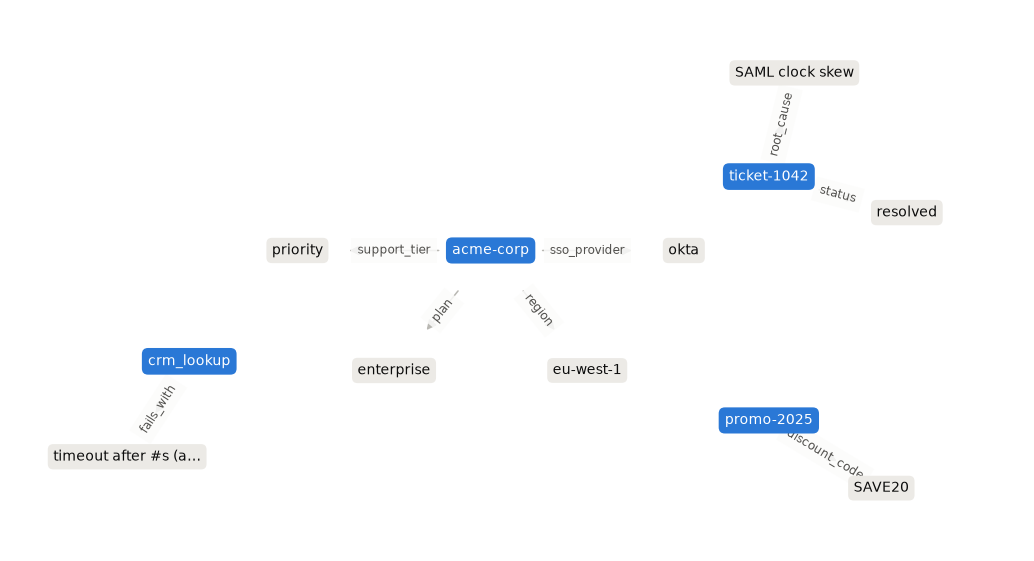

In [15]:
import math
import networkx as nx
import matplotlib.pyplot as plt

subjects = ("acme-corp", "ticket-1042", "crm_lookup", "promo-2025")
G = nx.DiGraph()
for subj in subjects:
    for g in json.loads(db.recall(subj, k=32)):
        f = g["fields"]
        if f["relation"] == "note":
            continue
        obj = str(f["object"])
        G.add_edge(f["subject"], obj if len(obj) <= 20 else obj[:19] + "…",
                   label=f["relation"])

# deterministic radial layout: subjects anchored, their values fanned outward
anchors = {"acme-corp": (0.0, 0.6), "ticket-1042": (3.6, 1.6),
           "crm_lookup": (-3.9, -0.9), "promo-2025": (3.6, -1.7)}
fans = {"acme-corp": (-90, 180), "ticket-1042": (30, 100),
        "crm_lookup": (-115, 1), "promo-2025": (-40, 1)}
radius = {"acme-corp": 2.5, "ticket-1042": 1.9, "crm_lookup": 1.9, "promo-2025": 1.9}
pos = dict(anchors)
for s, (sx, sy) in anchors.items():
    kids = [v for v in G.successors(s) if v not in pos]
    base, spread = fans[s]
    for i, v in enumerate(kids):
        a = math.radians(base + (i - (len(kids) - 1) / 2) * spread / max(len(kids) - 1, 1))
        pos[v] = (sx + radius[s] * math.cos(a), sy + radius[s] * 0.75 * math.sin(a))

fig, ax = plt.subplots(figsize=(9.5, 5.2), dpi=110)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#b9b8b3", arrows=True,
                       arrowsize=13, min_source_margin=34, min_target_margin=34)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="white",
    labels={n: n for n in G.nodes if n in subjects},
    bbox=dict(boxstyle="round,pad=0.45", fc="#2a78d6", ec="none"))
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="#0b0b0b",
    labels={n: n for n in G.nodes if n not in subjects},
    bbox=dict(boxstyle="round,pad=0.4", fc="#eceae6", ec="none"))
nx.draw_networkx_edge_labels(G, pos, ax=ax, font_size=8, font_color="#52514e",
    edge_labels=nx.get_edge_attributes(G, "label"), label_pos=0.5,
    bbox=dict(fc="#fcfcfb", ec="none", alpha=0.85))
ax.axis("off"); ax.margins(0.09); plt.tight_layout(); plt.show()

## 6 · Optional: LLM reflection (DISCOVER → GROUND → VERIFY)

Everything above ran with zero LLM calls. Adding a model lets Waiser *discover*
cross-fact issues determinism can't see — but drafts don't get a free pass:

- **GROUND**: every cited evidence hash is checked against the actual store;
- **VERIFY**: a *separate* pass judges soundness (proposer ≠ scorer), with a
  calibrated confidence floor of 0.75;
- the surviving drafts enter the same four-gate queue as everything else —
  **the LLM never gets write access**.

On the reproducible reference corpus, this verifier lifts Effective Reliability —
`(useful−wrong)/total`, a metric that *punishes* confident-wrong — from **+0.00
(no verifier) to +1.00**, at precision 1.00 / recall 1.00. That's the machinery
number (deterministic mock backend, planted positives + decoys), not a field claim
— reproduce it with `cargo run -p dejadb-bench --bin waiser_reflection`.

In [16]:
RUN_LLM_REFLECTION = False   # flip to True to run live (needs an API key)

if RUN_LLM_REFLECTION:
    try:                                   # Colab: store the key in the secrets panel
        from google.colab import userdata
        os.environ.setdefault("OPENROUTER_API_KEY", userdata.get("OPENROUTER_API_KEY"))
    except Exception:
        pass                               # elsewhere: export OPENROUTER_API_KEY
    run = json.loads(db.waiser_run(full_sweep=True, model="claude-opus-5"))
    # also accepted: "gpt-4o-mini", "ollama:llama3.1", "openrouter:openai/gpt-4o-mini",
    # or llm_cmd="..." to plug any local script (stdin/stdout JSON protocol).
    print(json.dumps(run, indent=2))
else:
    print("skipped — set RUN_LLM_REFLECTION = True to run live.")
    print('the call:  db.waiser_run(full_sweep=True, model="claude-opus-5")')

skipped — set RUN_LLM_REFLECTION = True to run live.
the call:  db.waiser_run(full_sweep=True, model="claude-opus-5")


## 7 · Plugging into your stack

**Claude's memory tool, natively.** `db.memory_tool()` implements Anthropic's
`memory_20250818` tool contract — wire it as the backend of Claude's built-in
memory tool and Claude reads/writes DejaDB directly:

In [17]:
db.memory_tool(json.dumps({"command": "create", "path": "/memories/acme.md",
                           "file_text": "Acme prefers async status updates.\n"}))
print(db.memory_tool(json.dumps({"command": "view", "path": "/memories"})))

Directory: /memories
/memories/acme.md


**Budget-aware context assembly.** CAL renders memory straight into model-ready
context — SML/TOON/Markdown/JSON — under an explicit token budget, in-process
(recall path has no server hop):

In [18]:
ctx = json.loads(db.cal(
    'ASSEMBLE "context for the acme call" '
    'FROM account: (RECALL facts WHERE subject = "acme-corp"), '
    '     lessons: (RECALL facts WHERE subject = "crm_lookup") '
    'BUDGET 300 tokens FORMAT markdown'))
print(ctx["text"])

### fact (4de645d9)
- **confidence**: 1.0
- **created_at**: 1785595296132
- **derived_from**: 0d33f5b5662a67a7aa217ca15f0d314624e0d68489ca69d8a39f884e2f353690
- **namespace**: support
- **object**: priority
- **relation**: support_tier
- **subject**: acme-corp
- **type**: fact

### fact (26581757)
- **confidence**: 0.9
- **created_at**: 1785595296122
- **namespace**: support
- **object**: priority
- **relation**: support_tier
- **subject**: acme-corp
- **type**: fact

### fact (6819ce04)
- **confidence**: 1.0
- **created_at**: 1785595295850
- **derived_from**: a04e565692b7bd601e3b3306c774cf1920dd7ca340b74d6efb73f13e2159100e
- **namespace**: support
- **object**: enterprise
- **relation**: plan
- **subject**: acme-corp
- **type**: fact

### fact (18bfad89)
- **confidence**: 0.9
- **created_at**: 1785595295844
- **namespace**: support
- **object**: eu-west-1
- **relation**: region
- **subject**: acme-corp
- **type**: fact

### fact (ded77119)
- **confidence**: 0.8
- **created_at**: 17855

**Vector recall, live.** Install any embedder — an in-process Python callable is
enough — and `RECALL … ABOUT` turns hybrid (structural + BM25 + vector, RRF-fused),
while `nearest()` becomes an advise-mode novelty check for writes (pair it with
`add_fact(..., idempotent=True)` for value-level dedup). This cell downloads a
~90 MB MiniLM model once; set the flag to `False` to skip:

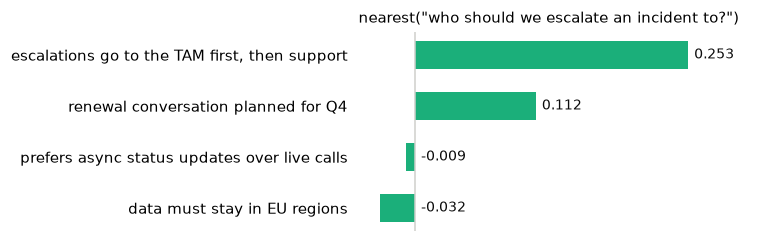

In [19]:
VECTOR_DEMO = True

if VECTOR_DEMO:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "fastembed"], check=True)
    from fastembed import TextEmbedding

    model = TextEmbedding("sentence-transformers/all-MiniLM-L6-v2")
    db.set_embedder(lambda t: [float(x) for x in list(model.embed([t]))[0]], "minilm")

    # grains written after the embedder is installed get vectors:
    for note in ["prefers async status updates over live calls",
                 "renewal conversation planned for Q4",
                 "escalations go to the TAM first, then support",
                 "data must stay in EU regions"]:
        db.add_fact("acme-corp", "note", note)

    text_of = {g["hash"]: str(g["fields"]["object"])
               for g in json.loads(db.recall("acme-corp", k=32))}
    hits = json.loads(db.nearest("who should we escalate an incident to?", k=4))

    import matplotlib.pyplot as plt
    labels = [text_of.get(h["hash"], "?") for h in hits][::-1]
    sims   = [h["similarity"] for h in hits][::-1]
    fig, ax = plt.subplots(figsize=(7.2, 2.3), dpi=110)
    bars = ax.barh(labels, sims, height=0.55, color="#1baf7a")
    for b, s in zip(bars, sims):
        ax.annotate(f"{s:.3f}", (max(s, 0), b.get_y() + b.get_height() / 2),
                    xytext=(4, 0), textcoords="offset points", va="center",
                    fontsize=9, color="#0b0b0b")
    ax.set_xlim(min(0, min(sims)) - 0.02, max(sims) * 1.3)
    ax.axvline(0, color="#d0cfcb", lw=1)
    ax.set_xticks([]); ax.tick_params(left=False)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_title('nearest("who should we escalate an incident to?")',
                 fontsize=10, loc="left")
    plt.tight_layout(); plt.show()
else:
    print("skipped — set VECTOR_DEMO = True to run.")

**Everything else speaks the same store:** a Node binding with the identical Waiser
surface (`npm i dejadb`), a CLI (`cargo install dejadb` → `deja waiser …`), a stdio
**MCP server** (6 tools incl. `dejadb_waiser`) for Claude Desktop/Code, a local web
console (memories, graph, query, Waiser review tabs), and `db.migrate(...)` importers
for **mem0, LangGraph, Letta, Zep, and tool-call JSONL** — bring your existing
memories with you.

## 8 · How this compares to Hermes Agent

[Hermes Agent](https://github.com/nousresearch/hermes-agent) (Nous Research, MIT,
Feb 2026) is the best-known open self-improving agent: a self-hosted daemon whose
learning loop writes skills and consolidates memory in a background post-turn
review. It's a great *agent runtime*. The two systems overlap on exactly one loop —
*agent-system learning* — and differ on what an enterprise has to trust:

| Self-improvement loop | Hermes Agent | DejaDB + Waiser |
|---|---|---|
| Proposes improvements from experience | ✅ (skills + memory synthesis) | ✅ (11 deterministic analyzers + optional LLM discovery) |
| **Write governance** | `memory.write_approval` and `skills.write_approval` both **default to off** (per its own docs; approval-before-write is an open feature request) | Four gates; **zero auto-apply by default**; policy-as-code grants, scoped + severity-capped; destructive ops double-gated |
| **Independent verification** | — (the proposing loop is the judge) | DISCOVER→GROUND→VERIFY: evidence grounded against the store, proposer ≠ scorer, 0.75 confidence floor |
| **Measured outcomes** | — | Baseline → current per applied change; held/regressed at 1d/7d/30d; regressions propose their own revert |
| **Audited undo** | ~ (files on disk; git if you set it up) | First-class: every apply records its inverse; rollback requires a reason |
| **Audit trail** | — (no formal audit log) | Actor + mandatory `because` on every decision, over immutable content-addressed history |
| **LLM-free core** | — (LLM drives the loop) | ✅ deterministic analyzers, keyless, air-gap friendly |
| Memory substrate | `USER.md`/`MEMORY.md` + SQLite FTS5 (+ optional external vector store) | Content-addressed grains, hybrid recall (structural+BM25+vector), single portable encrypted file, crypto-erasure |
| **Agent runtime** | ✅ persistent daemon, cron scheduler, 24/7 | — bring your own loop (any framework, MCP, or Claude's memory tool) |
| **Channels** | ✅ 16+ messaging platforms | — (MCP + HTTP hub; no chat connectors) |
| **UI** | community WebUI (chat-centric, ~self-hosted) | built-in local web console (memories/graph/query/Waiser review) |

Honest framing: **these are complementary more than they compete.** Hermes is a
runtime with an ungoverned learning loop; DejaDB+Waiser is an embedded memory +
*governed* learning engine that pairs with any runtime — including, in principle,
Hermes itself (its external memory tier is pluggable). If your agents touch
customer data, money, or production systems, the row that matters is governance:
*same loop, but proposed → reviewed → applied → measured, with an audit trail.*

*Design claims about Hermes are from its own repo/docs (write_approval defaults,
memory architecture); we deliberately cite its design, not its popularity numbers.*

## 9 · Take the wheel: the web console

Everything this notebook did programmatically has a point-and-click surface:
`deja ui` serves a local **web console** on the very same file — a memories
browser, an **interactive graph** view, a CAL query tab with a JSON tree / grain
inspector, and the **Waiser review queue**, where pending recommendations can be
approved, rejected, or applied (reasons required, same audit trail) from the
browser. Two things to know:

- **One memory = one file, single writer** — the console needs the file, so the
  cell below releases the notebook's handle first. Run it as your last step.
- **Token-less = read-only.** Browsing and queries work immediately; review
  *actions* require launching with a token
  (`DEJA_TOKEN=… deja ui --db support.db --token-env DEJA_TOKEN` — the browser
  asks for it via the native password prompt).

In [20]:
# release the notebook's handle first (single writer per memory file)
globals().pop("db", None)
import gc, os, shutil, subprocess, time, pathlib; gc.collect()

DEJA_VERSION = "v1.0.4"                 # release carrying the prebuilt CLI
IN_COLAB = "google.colab" in str(get_ipython())

deja = shutil.which("deja") or next(
    (str(p) for p in [pathlib.Path.home() / ".cargo/bin/deja", pathlib.Path("./deja")]
     if p.exists()), None)

if deja is None and IN_COLAB:           # fetch the prebuilt Linux CLI (no Rust toolchain)
    url = (f"https://github.com/AreevAI/dejadb/releases/download/{DEJA_VERSION}"
           "/deja-x86_64-unknown-linux-gnu.tar.gz")
    try:
        subprocess.run(f"curl -fsSL {url} | tar xz", shell=True, check=True)
        pathlib.Path("deja").chmod(0o755)
        deja = "./deja"
    except subprocess.CalledProcessError:
        print("prebuilt CLI not reachable — see github.com/AreevAI/dejadb/issues/38")

if deja:
    os.environ["DEJA_TOKEN"] = "demo"   # reviewing from the browser needs a token
    subprocess.Popen([deja, "ui", "--db", "support.db",
                      "--token-env", "DEJA_TOKEN", "--addr", "127.0.0.1:7437"])
    time.sleep(2)
    if IN_COLAB:                        # tunnel the VM's port to a clickable URL
        from google.colab.output import eval_js
        print("console →", eval_js("google.colab.kernel.proxyPort(7437)"))
    else:
        print("console → http://127.0.0.1:7437")
    print("sign in: any username, password 'demo'")
else:
    print("the console ships with the `deja` CLI:")
    print("  cargo install dejadb        # or, from a repo checkout:")
    print("  cargo run -p dejadb -- ui --db support.db")
    print("then open http://127.0.0.1:7437")

console → http://127.0.0.1:7437
sign in: any username, password 'demo'


## 10 · The enterprise checklist

| Requirement | In the box today |
|---|---|
| Audit & compliance | Immutable content-addressed history; actor + reason on every decision; stable `DOMAIN-Ennn` error codes |
| Data protection | AES-256-GCM encryption at rest (`passphrase=`); erasure = tombstone or crypto-erasure — the GDPR path is deleting a key, not scrubbing rows |
| Deployment | Embedded, no server in the recall path; runs air-gapped; Raspberry-Pi-class hardware is enough; local LLMs via Ollama |
| Portability | One memory = one file; `bundle`/`import_bundle` sync; OMS (Open Memory Spec) conformance — no vendor lock-in |
| Migration | `db.migrate()` importers: mem0, LangGraph, Letta, Zep, JSONL tool logs |
| Surfaces | Python · Node · Rust · CLI · MCP server · HTTP API + web console |

## 11 · What we're building next — tell us what you need

DejaDB is a memory engine, not an agent runtime — deliberately. The gaps we know
about, and are taking **feature requests** on for the enterprise roadmap:

- **Runtime integrations** — first-class recipes/adapters for Claude Agent SDK,
  LangGraph, CrewAI (today: examples + MCP + memory-tool).
- **Scheduled reflection** — a built-in `deja waiser watch` daemon/cron mode
  (today: `--if-stale` gating + your scheduler).
- **Channel connectors** — Slack/Teams/email surfaces for the review queue
  ("approve this recommendation from Slack").
- **Hosted console** — the web console is local-first today; a managed multi-store
  fleet view with SSO/RBAC is on the table.
- **Skill synthesis** — Waiser writes lessons as facts; distilling *procedural
  skills* from episodes is the next layer.
- **Prebuilt CLI binaries / one-line install** — so the console runs in Colab too
  ([#38](https://github.com/AreevAI/dejadb/issues/38)); bindings parity for the
  remaining governance surface ([#39](https://github.com/AreevAI/dejadb/issues/39)).

**Open an issue or discussion:** [github.com/AreevAI/dejadb](https://github.com/AreevAI/dejadb/issues)
— or bring it up live in the session. 🎤